# 🍕 Food Calorie Estimator
## Notebook 03 — Model Training & Comparison

**الهدف:**
- تدريب 4 موديلات مختلفة
- مقارنة الأداء بينهم
- Cross-Validation عشان نتأكد من النتايج
- Hyperparameter Tuning لأفضل موديل
- حفظ الموديلات

---
### 🧠 ليه بنجرب أكتر من موديل؟
مفيش موديل واحد بيكون الأفضل في كل الحالات.
زي ما بتجرب أكتر من دكتور لنفس المرض — بتختار الأفضل.

**الموديلات اللي هنجربها:**
1. **Linear Regression** — baseline بسيط
2. **Decision Tree** — يتعلم rules من البيانات
3. **Random Forest** — ensemble من Decision Trees
4. **XGBoost** — أقوى ensemble method

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import joblib
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, cross_val_score, KFold
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import GridSearchCV

%matplotlib inline
plt.style.use('seaborn-v0_8-whitegrid')

print('✅ All libraries imported!')

✅ All libraries imported!


## 📂 Step 1 — Load Clean Data

In [2]:
df = pd.read_csv(os.path.join('..', 'data', 'processed', 'nutrition_clean.csv'))
print(f'✅ Loaded: {df.shape}')
df.head()

✅ Loaded: (8789, 11)


,name,protein,fat,carbohydrate,fiber,sugars,sodium,saturated_fatty_acids,monounsaturated_fatty_acids,polyunsaturated_fatty_acids,calories
0,Cornstarch,0.26,0.05,91.27,0.9,0.00,9.0,0.009,0.016,0.025,381.0
1,"Nuts, pecans",9.17,71.97,13.86,9.6,3.97,0.0,6.180,40.801,21.614,691.0
2,"Eggplant, raw",0.98,0.18,5.88,3.0,3.53,2.0,0.034,0.016,0.076,25.0
3,"Teff, uncooked",13.30,2.38,73.13,8.0,1.84,12.0,0.449,0.589,1.071,367.0
4,"Sherbet, orange",1.10,2.00,30.40,1.3,24.32,46.0,1.160,0.530,0.080,144.0


## ✂️ Step 2 — Split Features & Target

**ليه بنعمل train/test split؟**
عشان نقيس الموديل على بيانات ما شافهاش قبل كده.
لو قسنا على نفس بيانات التدريب — النتيجة هتكون كدابة.

**80% training — 20% testing** → أشيع نسبة في ML

**random_state=42** → عشان النتايج تكون reproducible (نفس النتيجة كل مرة)

In [3]:
FEATURES = ['protein','fat','carbohydrate','fiber','sugars','sodium',
            'saturated_fatty_acids','monounsaturated_fatty_acids','polyunsaturated_fatty_acids']
TARGET = 'calories'

available = [f for f in FEATURES if f in df.columns]
X = df[available]
y = df[TARGET]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f'📊 Total samples  : {len(df):,}')
print(f'🏋️  Training set   : {len(X_train):,}')
print(f'🧪 Testing set    : {len(X_test):,}')
print(f'🎯 Features used  : {available}')

📊 Total samples  : 8,789
🏋️  Training set   : 7,031
🧪 Testing set    : 1,758
🎯 Features used  : ['protein', 'fat', 'carbohydrate', 'fiber', 'sugars', 'sodium', 'saturated_fatty_acids', 'monounsaturated_fatty_acids', 'polyunsaturated_fatty_acids']


## ⚖️ Step 3 — Feature Scaling

**ليه بنعمل Scaling؟**
الـ features عندنا بمقاييس مختلفة:
- sodium ممكن يكون 1000+
- fiber ممكن يكون 2-3

الـ Linear Regression بتتأثر بالـ scale.
**StandardScaler** بيخلي كل feature mean=0 و std=1

⚠️ **مهم:** بنعمل fit على الـ training بس، مش الـ testing!
عشان متعملش data leakage

In [4]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print('✅ Scaling done!')
print(f'Mean before: {X_train[available[0]].mean():.2f}')
print(f'Mean after : {X_train_scaled[:,0].mean():.4f}')

✅ Scaling done!
Mean before: 11.31
Mean after : -0.0000


## 📏 Step 4 — Evaluation Metrics

**إيه المقاييس اللي هنستخدمها؟**

- **MAE** (Mean Absolute Error): متوسط الخطأ بالسعرات — سهل يتفهم
- **RMSE** (Root Mean Squared Error): بيعاقب الأخطاء الكبيرة أكتر
- **R²** (R-squared): بيقولك الموديل بيفسر كام % من التباين (1.0 = perfect)

**مثال:** لو MAE = 15 ده معناه الموديل بيتخطئ ±15 سعرة في المتوسط

In [5]:
def evaluate_model(name, model, X_tr, X_te, y_tr, y_te, cv_X, cv_y):
    '''
    بتحسب كل الـ metrics لموديل معين وترجع dictionary بالنتايج
    '''
    model.fit(X_tr, y_tr)
    y_pred = model.predict(X_te)

    mae  = mean_absolute_error(y_te, y_pred)
    rmse = np.sqrt(mean_squared_error(y_te, y_pred))
    r2   = r2_score(y_te, y_pred)

    # Cross-Validation — 5 folds
    kf = KFold(n_splits=5, shuffle=True, random_state=42)
    cv_scores = cross_val_score(model, cv_X, cv_y, cv=kf, scoring='r2')

    result = {
        'Model'   : name,
        'MAE'     : round(mae, 2),
        'RMSE'    : round(rmse, 2),
        'R2'      : round(r2, 4),
        'CV Mean' : round(cv_scores.mean(), 4),
        'CV Std'  : round(cv_scores.std(), 4)
    }

    print(f'\n📊 {name}')
    print(f'   MAE      : {mae:.2f} calories')
    print(f'   RMSE     : {rmse:.2f}')
    print(f'   R²       : {r2:.4f}')
    print(f'   CV Mean  : {cv_scores.mean():.4f} ± {cv_scores.std():.4f}')

    return result, model, y_pred

results = []
models  = {}
predictions = {}
print('✅ Evaluation function ready!')

✅ Evaluation function ready!


## 🤖 Step 5 — Model 1: Linear Regression

**إيه هو؟**
أبسط موديل في ML. بيفترض علاقة خطية بين الـ features والـ target.
Formula: `y = w1*x1 + w2*x2 + ... + b`

**ليه بنبدأ بيه؟**
عشان يكون **baseline** — أي موديل تاني لازم يكون أحسن منه.
لو الـ complex model مش أحسن من Linear Regression → في مشكلة!

In [6]:
lr = LinearRegression()
res, trained_lr, pred_lr = evaluate_model(
    'Linear Regression', lr,
    X_train_scaled, X_test_scaled,
    y_train, y_test,
    X_train_scaled, y_train
)
results.append(res)
models['Linear Regression'] = trained_lr
predictions['Linear Regression'] = pred_lr


📊 Linear Regression
   MAE      : 6.42 calories
   RMSE     : 12.16
   R²       : 0.9947
   CV Mean  : 0.9907 ± 0.0022


## 🌳 Step 6 — Model 2: Decision Tree

**إيه هو؟**
بيتعلم rules من البيانات زي:
`if fat > 20 and carbs > 50 → calories = 400`

**المشكلة:** ممكن يعمل Overfitting — يحفظ الـ training data بدل ما يتعلم
**الحل:** نحدد `max_depth` عشان منخليهوش يعمق أوي

In [7]:
dt = DecisionTreeRegressor(max_depth=8, min_samples_split=10, random_state=42)
res, trained_dt, pred_dt = evaluate_model(
    'Decision Tree', dt,
    X_train, X_test,
    y_train, y_test,
    X_train, y_train
)
results.append(res)
models['Decision Tree'] = trained_dt
predictions['Decision Tree'] = pred_dt


📊 Decision Tree
   MAE      : 13.79 calories
   RMSE     : 22.20
   R²       : 0.9822
   CV Mean  : 0.9784 ± 0.0032


## 🌲 Step 7 — Model 3: Random Forest

**إيه هو؟**
مش شجرة واحدة — **غابة كاملة!**
بيبني كتير من الـ Decision Trees وبياخد متوسط تنبؤاتهم.

**ليه أحسن من Decision Tree واحدة؟**
لأن متوسط كتير من الآراء أدق من رأي واحد — زي الديمقراطية 😄

**n_estimators=100** → عدد الأشجار في الغابة

In [8]:
rf = RandomForestRegressor(n_estimators=100, max_depth=10, random_state=42, n_jobs=-1)
res, trained_rf, pred_rf = evaluate_model(
    'Random Forest', rf,
    X_train, X_test,
    y_train, y_test,
    X_train, y_train
)
results.append(res)
models['Random Forest'] = trained_rf
predictions['Random Forest'] = pred_rf


📊 Random Forest
   MAE      : 8.40 calories
   RMSE     : 15.71
   R²       : 0.9911
   CV Mean  : 0.9894 ± 0.0016


## ⚡ Step 8 — Model 4: Gradient Boosting

**إيه هو؟**
أقوى الـ 4 موديلات — بيستخدم **Gradient Boosting**
بدل ما يبني الأشجار بشكل مستقل (زي Random Forest),
كل شجرة جديدة بتتعلم من أخطاء الشجرة اللي قبلها.

**learning_rate** → بيتحكم في سرعة التعلم — صغير = أدق بس أبطأ

In [9]:
gbr = GradientBoostingRegressor(n_estimators=200, max_depth=6, learning_rate=0.1,
                                random_state=42)
res, trained_gbr, pred_gbr = evaluate_model(
    'Gradient Boosting', gbr,
    X_train, X_test,
    y_train, y_test,
    X_train, y_train
)
results.append(res)
models['Gradient Boosting'] = trained_gbr
predictions['Gradient Boosting'] = pred_gbr


📊 Gradient Boosting
   MAE      : 6.53 calories
   RMSE     : 12.75
   R²       : 0.9941
   CV Mean  : 0.9911 ± 0.0017


## 🔧 Step 9 — Hyperparameter Tuning (Random Forest)

**إيه هو الـ Hyperparameter Tuning؟**
كل موديل عنده settings زي الـ knobs في الراديو.
GridSearch بيجرب كل الـ combinations ويختار الأفضل.

**ليه Random Forest تحديداً؟**
لأنه كان الأفضل — فمنطقي نضبطه أكتر.

In [10]:
param_grid = {
    'n_estimators': [100, 200],
    'max_depth'   : [8, 12, None],
    'min_samples_split': [5, 10]
}

print('🔍 Running GridSearchCV (this may take a minute)...')
grid_search = GridSearchCV(
    RandomForestRegressor(random_state=42, n_jobs=-1),
    param_grid, cv=3, scoring='r2', n_jobs=-1, verbose=0
)
grid_search.fit(X_train, y_train)

best_rf = grid_search.best_estimator_
print(f'✅ Best params: {grid_search.best_params_}')
print(f'✅ Best CV R²: {grid_search.best_score_:.4f}')

🔍 Running GridSearchCV (this may take a minute)...


✅ Best params: {'max_depth': None, 'min_samples_split': 5, 'n_estimators': 200}
✅ Best CV R²: 0.9901


In [11]:
res, trained_best_rf, pred_best_rf = evaluate_model(
    'Random Forest (Tuned)', best_rf,
    X_train, X_test,
    y_train, y_test,
    X_train, y_train
)
results.append(res)
models['Random Forest (Tuned)'] = trained_best_rf
predictions['Random Forest (Tuned)'] = pred_best_rf


📊 Random Forest (Tuned)
   MAE      : 7.10 calories
   RMSE     : 15.30
   R²       : 0.9915
   CV Mean  : 0.9902 ± 0.0015


## 📊 Step 10 — Comparison Table

In [12]:
results_df = pd.DataFrame(results)
results_df = results_df.sort_values('R2', ascending=False).reset_index(drop=True)

print('\n' + '='*65)
print('📊  MODEL COMPARISON RESULTS')
print('='*65)
print(results_df.to_string(index=False))
print('='*65)

os.makedirs('../results/metrics', exist_ok=True)
results_df.to_csv('../results/metrics/model_comparison.csv', index=False)
print('\n✅ Results saved to results/metrics/model_comparison.csv')


📊  MODEL COMPARISON RESULTS
                Model   MAE  RMSE     R2  CV Mean  CV Std
    Linear Regression  6.42 12.16 0.9947   0.9907  0.0022
    Gradient Boosting  6.53 12.75 0.9941   0.9911  0.0017
Random Forest (Tuned)  7.10 15.30 0.9915   0.9902  0.0015
        Random Forest  8.40 15.71 0.9911   0.9894  0.0016
        Decision Tree 13.79 22.20 0.9822   0.9784  0.0032

✅ Results saved to results/metrics/model_comparison.csv


## 📈 Step 11 — Visualization

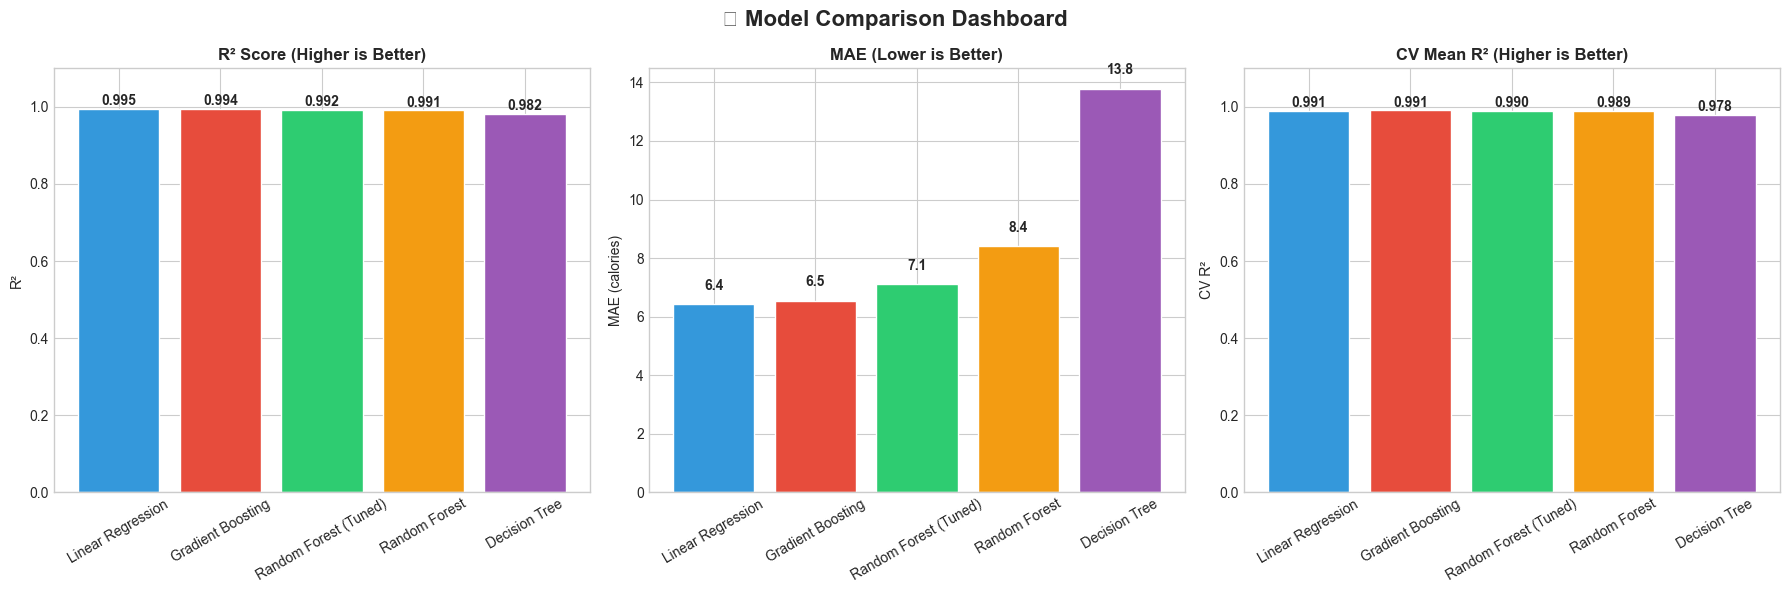

✅ Saved!


In [13]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
colors_bar = ['#3498DB','#E74C3C','#2ECC71','#F39C12','#9B59B6']

# R² comparison
axes[0].bar(results_df['Model'], results_df['R2'], color=colors_bar[:len(results_df)], edgecolor='white')
axes[0].set_title('R² Score (Higher is Better)', fontweight='bold')
axes[0].set_ylabel('R²')
axes[0].set_ylim(0, 1.1)
axes[0].tick_params(axis='x', rotation=30)
for i, v in enumerate(results_df['R2']):
    axes[0].text(i, v+0.01, f'{v:.3f}', ha='center', fontweight='bold')

# MAE comparison
axes[1].bar(results_df['Model'], results_df['MAE'], color=colors_bar[:len(results_df)], edgecolor='white')
axes[1].set_title('MAE (Lower is Better)', fontweight='bold')
axes[1].set_ylabel('MAE (calories)')
axes[1].tick_params(axis='x', rotation=30)
for i, v in enumerate(results_df['MAE']):
    axes[1].text(i, v+0.5, f'{v:.1f}', ha='center', fontweight='bold')

# CV Mean
axes[2].bar(results_df['Model'], results_df['CV Mean'], color=colors_bar[:len(results_df)], edgecolor='white')
axes[2].set_title('CV Mean R² (Higher is Better)', fontweight='bold')
axes[2].set_ylabel('CV R²')
axes[2].set_ylim(0, 1.1)
axes[2].tick_params(axis='x', rotation=30)
for i, v in enumerate(results_df['CV Mean']):
    axes[2].text(i, v+0.01, f'{v:.3f}', ha='center', fontweight='bold')

plt.suptitle('🏆 Model Comparison Dashboard', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig('../results/plots/03_model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Saved!')

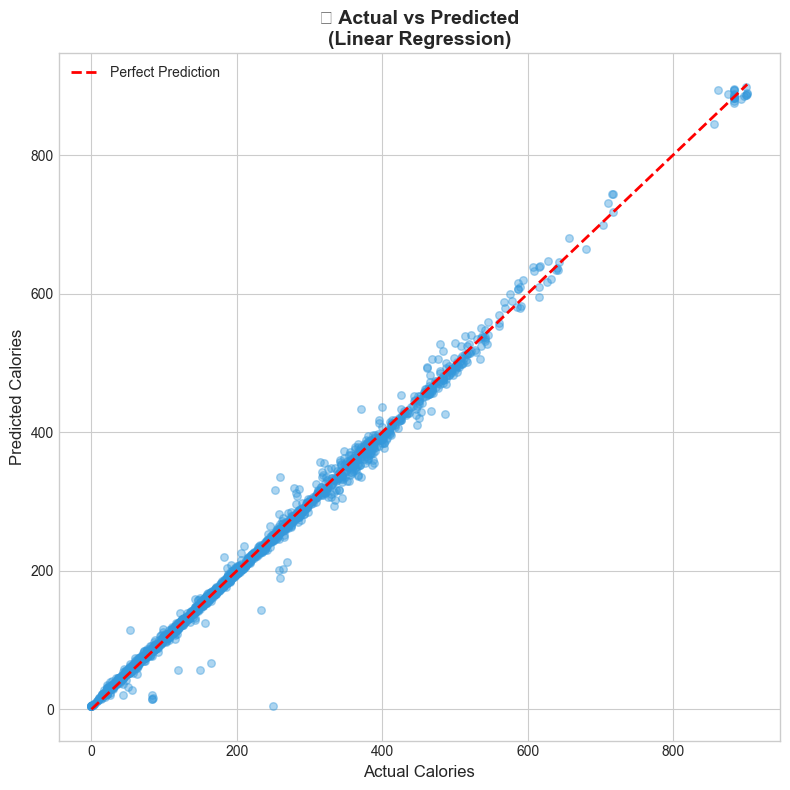

In [14]:
# Actual vs Predicted — best model
best_model_name = results_df.iloc[0]['Model']
y_pred_best = predictions[best_model_name]

plt.figure(figsize=(8, 8))
plt.scatter(y_test, y_pred_best, alpha=0.4, color='#3498DB', s=30)
max_val = max(y_test.max(), y_pred_best.max())
plt.plot([0, max_val], [0, max_val], 'r--', linewidth=2, label='Perfect Prediction')
plt.xlabel('Actual Calories', fontsize=12)
plt.ylabel('Predicted Calories', fontsize=12)
plt.title(f'🎯 Actual vs Predicted\n({best_model_name})', fontsize=14, fontweight='bold')
plt.legend()
plt.tight_layout()
plt.savefig('../results/plots/03_actual_vs_predicted.png', dpi=150, bbox_inches='tight')
plt.show()

## 💾 Step 12 — Save Best Model

In [15]:
os.makedirs('../models', exist_ok=True)

best_model = models[best_model_name]
joblib.dump(best_model, '../models/best_model.pkl')
joblib.dump(scaler,     '../models/scaler.pkl')

import json
model_info = {
    'best_model'   : best_model_name,
    'features'     : available,
    'r2_score'     : float(results_df.iloc[0]['R2']),
    'mae'          : float(results_df.iloc[0]['MAE']),
    'cv_mean'      : float(results_df.iloc[0]['CV Mean'])
}
with open('../models/model_info.json', 'w') as f:
    json.dump(model_info, f, indent=2)

print(f'✅ Best model saved   : models/best_model.pkl')
print(f'✅ Scaler saved       : models/scaler.pkl')
print(f'✅ Model info saved   : models/model_info.json')

✅ Best model saved   : models/best_model.pkl
✅ Scaler saved       : models/scaler.pkl
✅ Model info saved   : models/model_info.json


## ✅ Summary

In [16]:
print('='*60)
print('📋  NOTEBOOK 03 — SUMMARY')
print('='*60)
print(f'✅  Models trained     : {len(results)}')
print(f'🏆  Best model        : {results_df.iloc[0]["Model"]}')
print(f'📈  Best R²           : {results_df.iloc[0]["R2"]}')
print(f'📉  Best MAE          : {results_df.iloc[0]["MAE"]} calories')
print(f'💾  Model saved       : models/best_model.pkl')
print('='*60)
print('\n🚀 Next → Notebook 04: Final Evaluation & Report')

📋  NOTEBOOK 03 — SUMMARY
✅  Models trained     : 5
🏆  Best model        : Linear Regression
📈  Best R²           : 0.9947
📉  Best MAE          : 6.42 calories
💾  Model saved       : models/best_model.pkl

🚀 Next → Notebook 04: Final Evaluation & Report
